<a href="https://colab.research.google.com/github/Lucasgomesbit/engenharia_de_prompt_e_aplicacoes/blob/main/aula08_AutomacaoIA_4f.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aula 8:
Nome Lucas Kelvin Gomes da Paz

Crie um script Python simples para verificar a temperatura e um sistema. Se for maior que 30, exiba um alerta de superaqeucimento.


In [5]:
# Este script verifica a temperatura e exibe um alerta de superaquecimento se for maior que 30°C.
temperatura = float(input("Digite a temperatura atual em °C: "))

if temperatura > 30:
    print(f"ALERTA: Superaquecimento! Temperatura atual: {temperatura}°C")
else:
    print(f"Temperatura normal: {temperatura}°C")

Digite a temperatura atual em °C: 52
ALERTA: Superaquecimento! Temperatura atual: 52.0°C


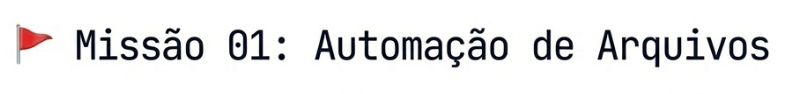


Criar um programa que organize arquivos bagunçados em pastas automaticamente, baseando se apnas na extensão do arquivo(ex: .pdf, .jpg). (Utilize biblioteca Os ou shutil).


In [10]:
import os
import shutil

def organizar_arquivos(diretorio_origem):
    if not os.path.isdir(diretorio_origem):
        print(f"Erro: O diretório '{diretorio_origem}' não existe.")
        return

    print(f"Organizando arquivos em: {diretorio_origem}")

    for filename in os.listdir(diretorio_origem):
        file_path = os.path.join(diretorio_origem, filename)

        # Ignorar diretórios e arquivos ocultos (opcional)
        if os.path.isdir(file_path) or filename.startswith('.'):
            continue

        # Obter a extensão do arquivo
        _, extension = os.path.splitext(filename)
        extension = extension.lower() # Converter para minúsculas para padronização

        if not extension: # Arquivos sem extensão
            pasta_destino = os.path.join(diretorio_origem, "sem_extensao")
        else:
            # Remover o ponto da extensão para usar como nome da pasta
            pasta_destino = os.path.join(diretorio_origem, extension[1:])

        # Criar a pasta de destino se ela não existir
        os.makedirs(pasta_destino, exist_ok=True)

        # Mover o arquivo para a pasta de destino
        try:
            shutil.move(file_path, os.path.join(pasta_destino, filename))
            print(f"Movido '{filename}' para '{pasta_destino}'")
        except Exception as e:
            print(f"Erro ao mover '{filename}': {e}")

# Solicitar ao usuário o diretório a ser organizado
if __name__ == "__main__":
    # Use o diretório atual como padrão ou peça ao usuário
    diretorio_para_organizar = input("Digite o caminho do diretório a ser organizado (pressione Enter para usar o diretório atual): ")

    if not diretorio_para_organizar:
        diretorio_para_organizar = os.getcwd() # Diretório de trabalho atual
        print(f"Usando o diretório atual: {diretorio_para_organizar}")

    organizar_arquivos(diretorio_para_organizar)
    print("Organização concluída!")

Digite o caminho do diretório a ser organizado (pressione Enter para usar o diretório atual): imagens
Erro: O diretório 'imagens' não existe.
Organização concluída!


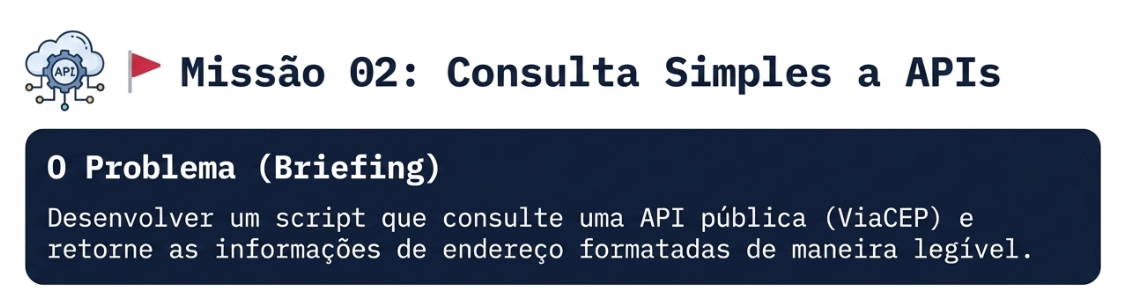

In [20]:
import requests
import json # Importar json para tratar erros de decodificação JSON

def consultar_cep_viacep(cep):
    """
    Consulta a API ViaCEP para obter informações de endereço.
    Retorna um dicionário com os dados do endereço ou None em caso de erro.
    """
    # Remove quaisquer caracteres não numéricos do CEP
    cep = ''.join(filter(str.isdigit, cep))

    if len(cep) != 8:
        print("Erro: O CEP deve conter exatamente 8 dígitos numéricos.")
        return None

    url = f"https://viacep.com.br/ws/{cep}/json/"
    try:
        response = requests.get(url)
        response.raise_for_status()  # Lança uma exceção para códigos de status HTTP de erro (4xx ou 5xx)
        data = response.json()

        if 'erro' in data and data['erro']:
            print(f"CEP '{cep}' não encontrado ou inválido.")
            return None
        else:
            return data
    except requests.exceptions.RequestException as e:
        print(f"Erro de conexão ou HTTP ao consultar a API ViaCEP: {e}")
        return None
    except json.JSONDecodeError as e:
        print(f"Erro ao decodificar a resposta JSON da API: {e}")
        return None
    except Exception as e:
        print(f"Ocorreu um erro inesperado ao consultar o CEP: {e}")
        return None

def formatar_endereco(dados_endereco):
    """
    Formata os dados de endereço em uma string legível.
    """
    if not dados_endereco:
        return "Nenhum dado de endereço para formatar."

    endereco_formatado = f"Endereço para o CEP {dados_endereco.get('cep', 'N/A')}:\n"
    endereco_formatado += f"  Logradouro: {dados_endereco.get('logradouro', 'N/A')}\n"
    endereco_formatado += f"  Complemento: {dados_endereco.get('complemento', 'N/A')}\n"
    endereco_formatado += f"  Bairro: {dados_endereco.get('bairro', 'N/A')}\n"
    endereco_formatado += f"  Cidade: {dados_endereco.get('localidade', 'N/A')}\n"
    endereco_formatado += f"  Estado: {dados_endereco.get('uf', 'N/A')}\n"
    endereco_formatado += f"  IBGE: {dados_endereco.get('ibge', 'N/A')}\n"
    endereco_formatado += f"  GIA: {dados_endereco.get('gia', 'N/A')}\n"
    endereco_formatado += f"  DDD: {dados_endereco.get('ddd', 'N/A')}\n"
    endereco_formatado += f"  SIAFI: {dados_endereco.get('siafi', 'N/A')}"
    return endereco_formatado

# Exemplo de uso
if __name__ == "__main__":
    try:
        cep_digitado = input("Digite o CEP para consulta (somente números): ")

        dados = consultar_cep_viacep(cep_digitado)

        if dados:
            print("\n--- Informações do Endereço ---")
            print(formatar_endereco(dados))
        else:
            print("Não foi possível obter as informações do endereço.")
    except KeyboardInterrupt:
        print("\nOperação cancelada pelo usuário.")
    except Exception as e:
        print(f"\nOcorreu um erro inesperado na execução principal: {e}")

Digite o CEP para consulta (somente números): 72885560

--- Informações do Endereço ---
Endereço para o CEP 72885-560:
  Logradouro: Quadra 7
  Complemento: 
  Bairro: Mansões Recreio Mossoró
  Cidade: Cidade Ocidental
  Estado: GO
  IBGE: 5205497
  GIA: 
  DDD: 61
  SIAFI: 0077


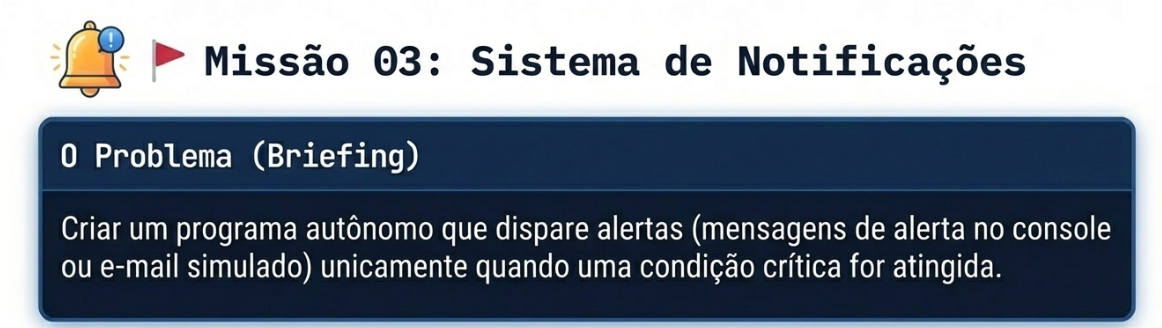

In [16]:
import time
import random

def simular_leitura_sensor():
    """
    Simula a leitura de um sensor, retornando um valor numérico aleatório.
    Os valores são gerados entre 20 e 40 para simular um cenário onde uma
    condição crítica (acima de 30) pode ser atingida ou não.
    Retorna:
        float: O valor da leitura simulada do sensor.
    """
    # Simula valores entre 20 e 40 para demonstrar a condição crítica
    return random.uniform(20, 40)

def disparar_alerta(mensagem, tipo_alerta="console"):
    """
    Dispara uma mensagem de alerta, exibindo-a no console ou simulando
    o envio de um e-mail.
    Args:
        mensagem (str): A mensagem de alerta a ser exibida.
        tipo_alerta (str): O tipo de alerta. Pode ser 'console' ou 'email_simulado'.
                           Padrão é 'console'.
    """
    timestamp = time.strftime("%Y-%m-%d %H:%M:%S")
    if tipo_alerta == "console":
        print(f"[{timestamp}] ALERTA CRÍTICO (Console): {mensagem}")
    elif tipo_alerta == "email_simulado":
        print(f"[{timestamp}] ALERTA CRÍTICO (Email Simulado): Enviando e-mail para admin@exemplo.com com a mensagem: {mensagem}")
    else:
        print(f"[{timestamp}] ALERTA CRÍTICO (Tipo desconhecido): {mensagem}")

def programa_autonomo_monitoramento(intervalo_segundos=5, limite_leituras=10, limiar_critico=35):
    """
    Programa autônomo que monitora um valor simulado de sensor e dispara alertas
    quando o valor excede um limiar crítico.
    Args:
        intervalo_segundos (int): O intervalo de tempo em segundos entre cada leitura do sensor.
        limite_leituras (int): O número máximo de leituras a serem realizadas antes que o programa termine.
        limiar_critico (float): O valor numérico acima do qual a leitura do sensor é considerada crítica.
    """
    print(f"Iniciando monitoramento autônomo. Limiar crítico: {limiar_critico}°C. Intervalo: {intervalo_segundos}s.")
    print("Pressione Ctrl+C a qualquer momento para parar o monitoramento.")

    leituras_realizadas = 0
    try:
        while leituras_realizadas < limite_leituras:
            valor_atual = simular_leitura_sensor()
            print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] Leitura atual: {valor_atual:.2f}°C")

            # Verifica se a condição crítica foi atingida
            if valor_atual > limiar_critico:
                mensagem_alerta = f"Valor de {valor_atual:.2f}°C excedeu o limiar crítico de {limiar_critico}°C!"
                disparar_alerta(mensagem_alerta, tipo_alerta="console")
                disparar_alerta(mensagem_alerta, tipo_alerta="email_simulado") # Simula o envio de um e-mail
                print("--- ALERTA DISPARADO ---")

            leituras_realizadas += 1
            time.sleep(intervalo_segundos)

    except KeyboardInterrupt:
        # Captura interrupção do usuário (Ctrl+C)
        print("\nMonitoramento interrompido pelo usuário.")
    except Exception as e:
        # Captura outros erros inesperados
        print(f"\nOcorreu um erro inesperado durante o monitoramento: {e}")
    finally:
        print("Monitoramento encerrado.")

# Exemplo de uso do programa autônomo
if __name__ == "__main__":
    # Você pode ajustar esses parâmetros conforme necessário
    intervalo = 3         # Intervalo de 3 segundos entre as leituras
    num_leituras = 15     # Realizar 15 leituras
    limiar = 30.0         # Limiar crítico de 30°C

    programa_autonomo_monitoramento(
        intervalo_segundos=intervalo,
        limite_leituras=num_leituras,
        limiar_critico=limiar
    )

Iniciando monitoramento autônomo. Limiar crítico: 30.0°C. Intervalo: 3s.
Pressione Ctrl+C a qualquer momento para parar o monitoramento.
[2026-04-16 00:39:35] Leitura atual: 21.30°C
[2026-04-16 00:39:38] Leitura atual: 36.55°C
[2026-04-16 00:39:38] ALERTA CRÍTICO (Console): Valor de 36.55°C excedeu o limiar crítico de 30.0°C!
[2026-04-16 00:39:38] ALERTA CRÍTICO (Email Simulado): Enviando e-mail para admin@exemplo.com com a mensagem: Valor de 36.55°C excedeu o limiar crítico de 30.0°C!
--- ALERTA DISPARADO ---
[2026-04-16 00:39:41] Leitura atual: 32.34°C
[2026-04-16 00:39:41] ALERTA CRÍTICO (Console): Valor de 32.34°C excedeu o limiar crítico de 30.0°C!
[2026-04-16 00:39:41] ALERTA CRÍTICO (Email Simulado): Enviando e-mail para admin@exemplo.com com a mensagem: Valor de 32.34°C excedeu o limiar crítico de 30.0°C!
--- ALERTA DISPARADO ---
[2026-04-16 00:39:44] Leitura atual: 26.69°C
[2026-04-16 00:39:47] Leitura atual: 26.97°C
[2026-04-16 00:39:50] Leitura atual: 20.25°C
[2026-04-16 00: